In [9]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Rescaling, RandomFlip, RandomRotation, RandomZoom, RandomTranslation, Dropout, RandomContrast, Input

from keras.utils import image_dataset_from_directory
from keras.models import Sequential

import math

In [ ]:
dir = "/kaggle/input/datasetimagenesmascarilla/data"

IMG_SIZE = (128, 128) 
BATCH_SIZE = 32

In [11]:
dataset_entero = tf.keras.preprocessing.image_dataset_from_directory(
    dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Found 7553 files belonging to 2 classes.


In [12]:
# Convertir el Dataset en un array para poder dividirlo
imagenes = []
etiquetas = []

# Cargar imágenes y etiquetas en listas (2 elementos dada la estructura de datos)
for imagen_batch, etiqueta_batch in dataset_entero:
    imagenes.append(imagen_batch.numpy())
    etiquetas.append(etiqueta_batch.numpy())

imagenes = np.concatenate(imagenes)
etiquetas = np.concatenate(etiquetas)

# Dividir el conjunto de datos en entrenamiento (80%), validación (10%) y test (10%)
X_train, X_temp, y_train, y_temp = train_test_split(imagenes, etiquetas, test_size=0.2, random_state=123)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=123)

# Volver a convertir a datasets de TensorFlow
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

In [ ]:
print(train_dataset)
print(train_dataset.element_spec)

for batch, labels in train_dataset.take(1):
    print(batch.shape)

<_BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))
(32, 128, 128, 3)


"\nprint('Training data shape : ', train_dataset.shape)\nprint('Testing data shape : ', test_dataset.shape)\n"

In [ ]:
normalization = Rescaling(1.0 / 255)

data_augmentation = Sequential(
    [
        RandomFlip("horizontal"),  # Volteo horizontal
        RandomRotation(0.3),  # Rotaciones 20% de 360º
        RandomZoom(0.3),  # Zoom hasta 10%
        RandomContrast(0.2),
    ]
)

train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization(x)), y))
val_dataset = val_dataset.map(lambda x, y: (normalization(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization(x), y))

In [ ]:
model = keras.Sequential(
    [  
        Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        Conv2D(64, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        Conv2D(128, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        Flatten(),
        Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01)),
        Dropout(0.2),
        Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,665 (12.61 MB)

 Trainable params: 3,305,217 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit( train_dataset, validation_data=val_dataset, epochs=20, batch_size=32, callbacks=[early_stop] )

Epoch 1/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 38s 149ms/step - accuracy: 0.7133 - loss: 4.6155 - val_accuracy: 0.5351 - val_loss: 3.3714
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 114ms/step - accuracy: 0.8409 - loss: 1.0043 - val_accuracy: 0.5325 - val_loss: 2.1614
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - accuracy: 0.8327 - loss: 0.7923 - val_accuracy: 0.5987 - val_loss: 5.7623
Epoch 4/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - accuracy: 0.8242 - loss: 1.1766 - val_accuracy: 0.7126 - val_loss: 1.0671
Epoch 5/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 115ms/step - accuracy: 0.8403 - loss: 0.6051 - val_accuracy: 0.6000 - val_loss: 2.0272
Epoch 6/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - accuracy: 0.8497 - loss: 0.8260 - val_accuracy: 0.7841 - val_loss: 0.9399
Epoch 7/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 114ms/step - accuracy: 0.8452 - loss: 0.7777 - val_accuracy: 0.8265 - val_loss: 0.6064
Epoch 8/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.8568 - loss: 0

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
               precision    recall  f1-score   support

   Mascarilla       0.92      0.82      0.87       395
No Mascarilla       0.83      0.92      0.87       361

     accuracy                           0.87       756
    macro avg       0.87      0.87      0.87       756
 weighted avg       0.87      0.87      0.87       756



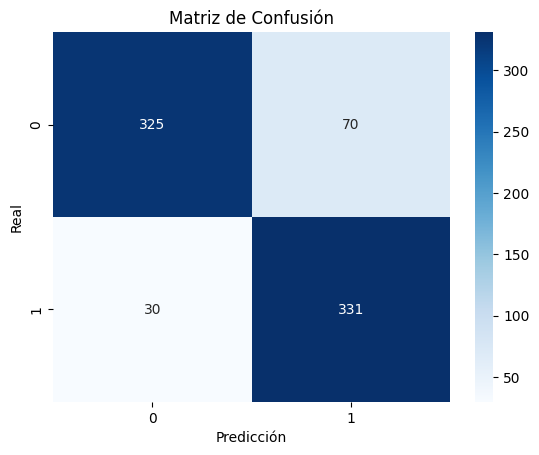

In [17]:
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_pred = model.predict(test_dataset)
y_pred = (y_pred > 0.5).astype("int32").flatten()

# Reporte de clasificación
print(classification_report(y_true, y_pred, target_names=["Mascarilla", "No Mascarilla"]))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8679 - loss: 0.4959
Pérdida en test: 0.5015
Precisión en test: 0.8677


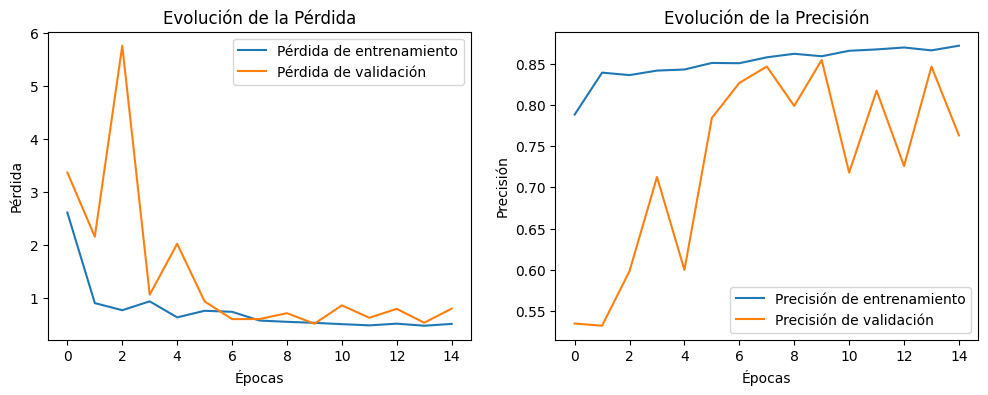

In [18]:
# Evaluación del modelo en el conjunto de test
loss, accuracy = model.evaluate(test_dataset)

print(f"Pérdida en test: {loss:.4f}")
print(f"Precisión en test: {accuracy:.4f}")

# Extraer los valores del historial
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(len(train_loss))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Pérdida de entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Evolución de la Pérdida')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Precisión de entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión de validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.title('Evolución de la Precisión')

plt.show()